Day1 : Dataset Understanding

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install tensorflow[and-cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 91.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalli

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2



In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brian-tumor-dataset' dataset.
Path to dataset files: /kaggle/input/brian-tumor-dataset


In [6]:
print(os.listdir(path))

['metadata_rgb_only.csv', 'Brain Tumor Data Set', 'metadata.csv']


In [7]:
path1=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set")
print(os.listdir(path1))

['Brain Tumor', 'Healthy']


In [8]:
images_path=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Brain Tumor")
print(images_path)

/kaggle/input/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor


In [9]:
print(len(os.listdir(images_path)))
print(os.listdir(images_path)[:5])

2513
['Cancer (489).jpg', 'Cancer (72).tif', 'Cancer (2411).jpg', 'Cancer (1065).jpg', 'Cancer (1014).jpg']


In [10]:
import pandas as pd
import os

data = []

folder_name = "Brain Tumor"
count = len(os.listdir(images_path))

data.append((folder_name, count))

print(f"{folder_name}: {count} images")

df = pd.DataFrame(data, columns=["Class", "Count"])
df

Brain Tumor: 2513 images


,Class,Count
0,Brain Tumor,2513


In [11]:
images_pathhealthy=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Healthy")
print(images_pathhealthy)

/kaggle/input/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Healthy


In [12]:
print(len(os.listdir(images_pathhealthy)))
print(os.listdir(images_pathhealthy)[:5])

2087
['Not Cancer  (446).jpg', 'Not Cancer  (1646).jpg', 'Not Cancer  (1548).jpg', 'Not Cancer  (1864).jpg', 'Not Cancer  (1736).jpg']


In [13]:
import pandas as pd
import os

data = []

# Brain Tumor
tumor_images = [img for img in os.listdir(images_path) if img.endswith(('.jpg', '.png', '.tif'))]
tumor_count = len(tumor_images)
data.append(("Brain Tumor", tumor_count))

print(f"Brain Tumor: {tumor_count} images")

# Healthy
healthy_images = [img for img in os.listdir(images_pathhealthy) if img.endswith(('.jpg', '.png', '.tif'))]
healthy_count = len(healthy_images)
data.append(("Healthy", healthy_count))

print(f"Healthy: {healthy_count} images")


# Create DataFrame
df = pd.DataFrame(data, columns=["Class", "Count"])

df

Brain Tumor: 2445 images
Healthy: 2075 images


,Class,Count
0,Brain Tumor,2445
1,Healthy,2075


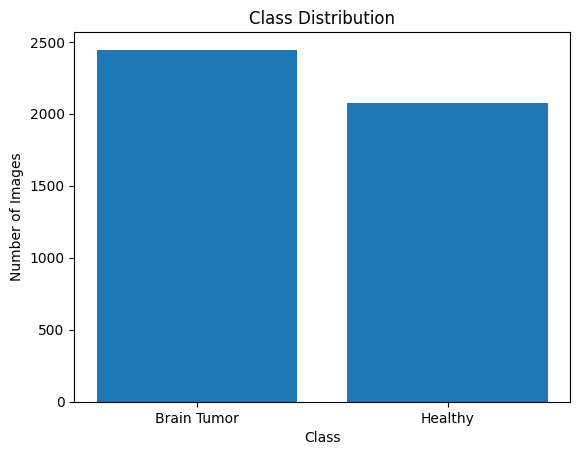

In [ ]:
plt.bar(df["Class"], df["Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
from PIL import Image
import os

sizes = []

# Brain Tumor images
for img_name in os.listdir(images_path)[:50]:  # sample
    img_path = os.path.join(images_path, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

# Healthy images
for img_name in os.listdir(images_pathhealthy)[:50]:  # sample
    img_path = os.path.join(images_pathhealthy, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

print("Sample Image Sizes:", sizes[:10])

Sample Image Sizes: [(512, 512), (256, 256), (248, 338), (630, 630), (278, 351), (512, 512), (258, 279), (273, 318), (512, 512), (512, 512)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load one sample image
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))

print("Min pixel value:", img.min())
print("Max pixel value:", img.max())
print("Mean brightness:", img.mean())

Min pixel value: 0
Max pixel value: 255
Mean brightness: 28.690746307373047


In [ ]:
brightness_values = []

for img_name in os.listdir(images_path)[:50]:
    img = plt.imread(os.path.join(images_path, img_name))
    brightness_values.append(img.mean())

print("Average brightness:", sum(brightness_values)/len(brightness_values))

Average brightness: 65.85444162454017


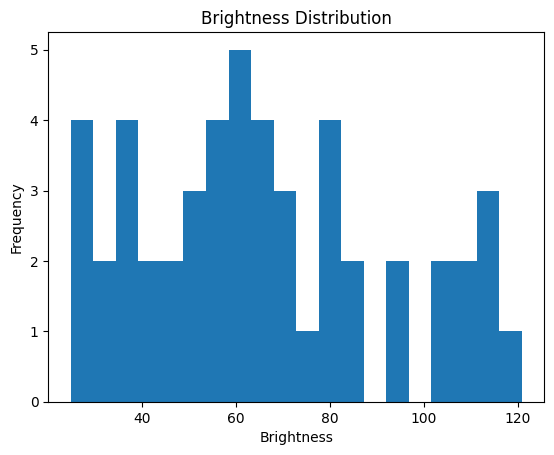

In [ ]:
plt.hist(brightness_values, bins=20)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

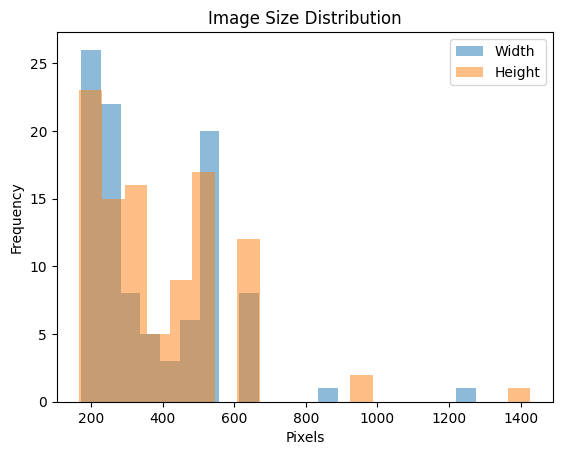

In [ ]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.hist(widths, bins=20, alpha=0.5, label='Width')
plt.hist(heights, bins=20, alpha=0.5, label='Height')
plt.legend()
plt.title("Image Size Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import hashlib

hashes = set()
duplicates = 0

for img_name in os.listdir(images_path)[:100]:
    with open(os.path.join(images_path, img_name), 'rb') as f:
        filehash = hashlib.md5(f.read()).hexdigest()
        if filehash in hashes:
            duplicates += 1
        else:
            hashes.add(filehash)

print("Duplicate images:", duplicates)

Duplicate images: 1


In [ ]:
df["Percentage"] = (df["Count"] / df["Count"].sum()) * 100
df

,Class,Count,Percentage
0,Brain Tumor,2445,54.09292
1,Healthy,2075,45.90708


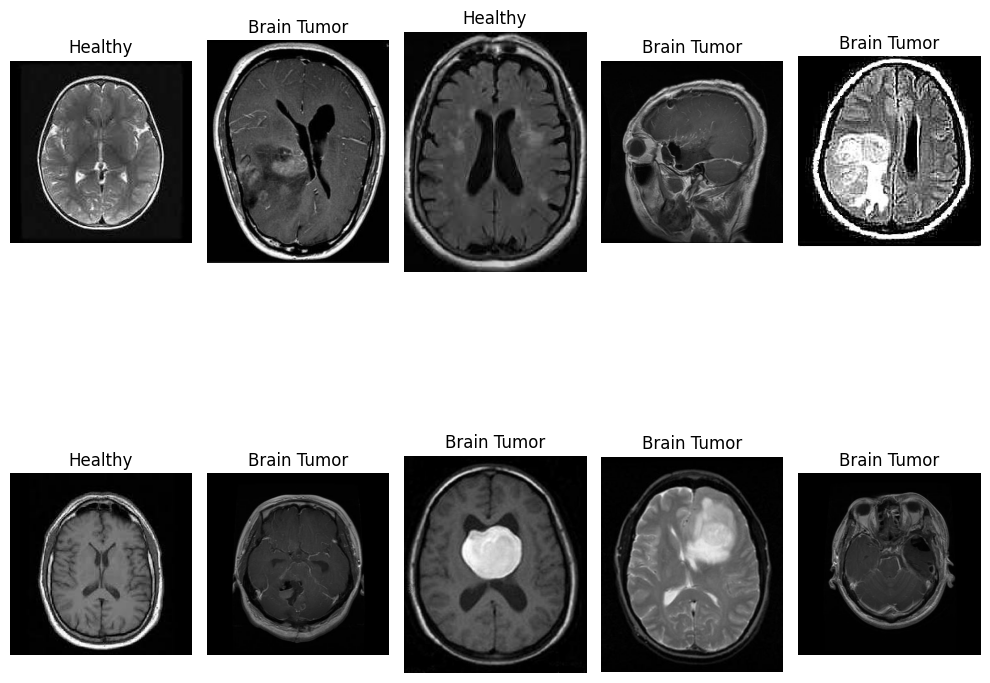

In [ ]:
import matplotlib.pyplot as plt
import random
import os

plt.figure(figsize=(10, 10))

for i in range(10):

    # Randomly choose class
    if random.random() > 0.5:
        folder = "Brain Tumor"
        folder_path = images_path
    else:
        folder = "Healthy"
        folder_path = images_pathhealthy

    # Pick random image
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = plt.imread(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image mode:", img.mode)

Image mode: RGB


In [ ]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image mode:", img.mode)

Image mode: RGB


In [ ]:
from PIL import Image

corrupted = 0

for img_name in os.listdir(images_path):
    try:
        img = Image.open(os.path.join(images_path, img_name))
    except:
        corrupted += 1

print("Corrupted images:", corrupted)

Corrupted images: 0


In [ ]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image shape:", img.shape)

Image shape: (512, 512, 3)


In [ ]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image shape:", img.shape)

Image shape: (512, 512, 3)


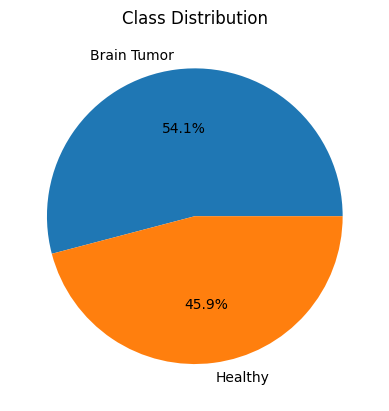

In [ ]:
plt.pie(df["Count"], labels=df["Class"], autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

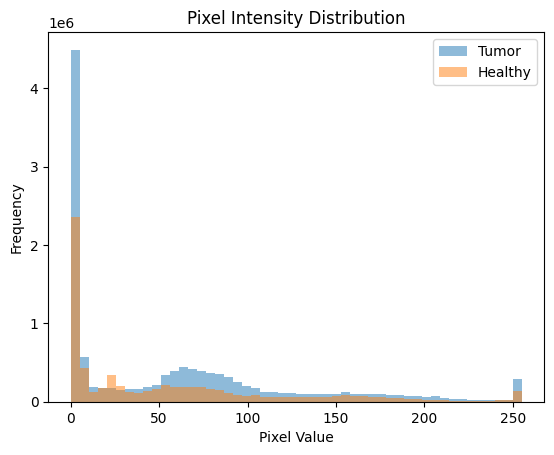

In [ ]:
tumor_pixels = []
healthy_pixels = []

# Tumor
for img_name in os.listdir(images_path)[:20]:
    img = plt.imread(os.path.join(images_path, img_name))
    tumor_pixels.extend(img.flatten())

# Healthy
for img_name in os.listdir(images_pathhealthy)[:20]:
    img = plt.imread(os.path.join(images_pathhealthy, img_name))
    healthy_pixels.extend(img.flatten())

# Plot
plt.hist(tumor_pixels, bins=50, alpha=0.5, label='Tumor')
plt.hist(healthy_pixels, bins=50, alpha=0.5, label='Healthy')
plt.legend()
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
label_map = {
    "Healthy": 0,
    "Brain Tumor": 1
}

print(label_map)

{'Healthy': 0, 'Brain Tumor': 1}


In [ ]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Min pixel:", img.min())
print("Max pixel:", img.max())

Min pixel: 0
Max pixel: 255


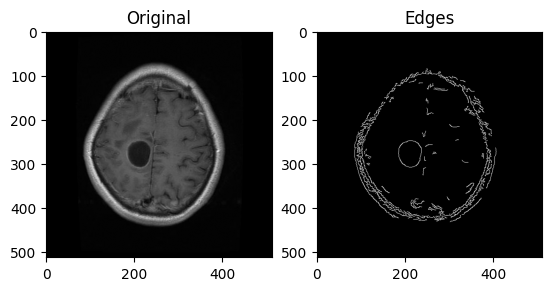

In [ ]:
import cv2

img_path = os.path.join(images_path, os.listdir(images_path)[0])
img = cv2.imread(img_path, 0)

edges = cv2.Canny(img, 100, 200)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.show()

/tmp/ipykernel_29769/3694909810.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tumor_mean, healthy_mean], labels=["Tumor", "Healthy"])


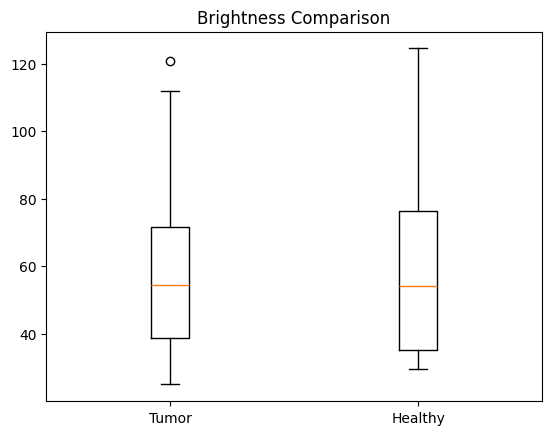

In [ ]:
tumor_mean = []
healthy_mean = []

for img_name in os.listdir(images_path)[:20]:
    img = plt.imread(os.path.join(images_path, img_name))
    tumor_mean.append(img.mean())

for img_name in os.listdir(images_pathhealthy)[:20]:
    img = plt.imread(os.path.join(images_pathhealthy, img_name))
    healthy_mean.append(img.mean())

plt.boxplot([tumor_mean, healthy_mean], labels=["Tumor", "Healthy"])
plt.title("Brightness Comparison")
plt.show()


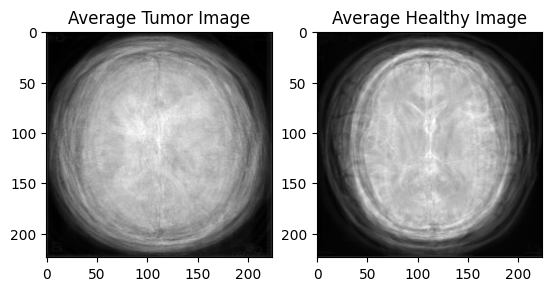

In [ ]:
import numpy as np
import cv2

def average_image(folder_path):
    images = []

    for img_name in os.listdir(folder_path)[:50]:
        img = cv2.imread(os.path.join(folder_path, img_name), 0)
        img = cv2.resize(img, (224, 224))
        images.append(img)

    return np.mean(images, axis=0)

tumor_avg = average_image(images_path)
healthy_avg = average_image(images_pathhealthy)

plt.subplot(1,2,1)
plt.imshow(tumor_avg, cmap='gray')
plt.title("Average Tumor Image")

plt.subplot(1,2,2)
plt.imshow(healthy_avg, cmap='gray')
plt.title("Average Healthy Image")

plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

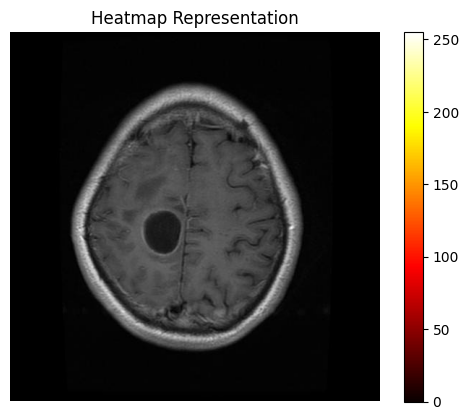

In [ ]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
plt.imshow(img, cmap='hot')
plt.colorbar()
plt.title("Heatmap Representation")
plt.axis('off')

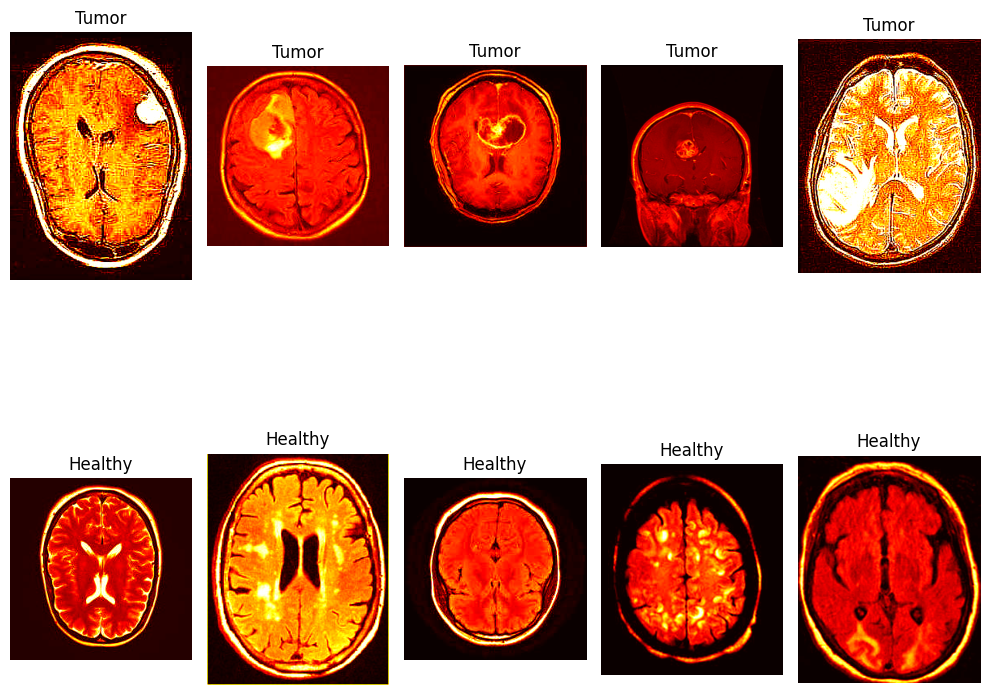

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2
import random

plt.figure(figsize=(10, 10))

# Tumor images
for i in range(5):
    img_name = random.choice(os.listdir(images_path))
    img = cv2.imread(os.path.join(images_path, img_name), 0)

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='hot')
    plt.title("Tumor")
    plt.axis('off')

# Healthy images
for i in range(5):
    img_name = random.choice(os.listdir(images_pathhealthy))
    img = cv2.imread(os.path.join(images_pathhealthy, img_name), 0)

    plt.subplot(2, 5, i+6)
    plt.imshow(img, cmap='hot')
    plt.title("Healthy")
    plt.axis('off')

plt.tight_layout()
plt.show()

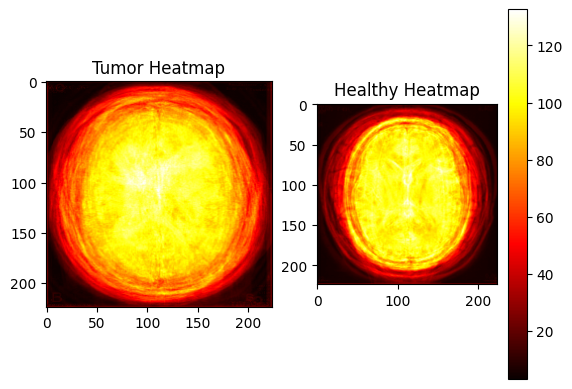

In [ ]:
import numpy as np
import cv2

def avg_heatmap(folder):
    imgs = []

    for img_name in os.listdir(folder)[:50]:
        img = cv2.imread(os.path.join(folder, img_name), 0)
        img = cv2.resize(img, (224, 224))
        imgs.append(img)

    return np.mean(imgs, axis=0)

tumor_avg = avg_heatmap(images_path)
healthy_avg = avg_heatmap(images_pathhealthy)

plt.subplot(1,2,1)
plt.imshow(tumor_avg, cmap='hot')
plt.title("Tumor Heatmap")

plt.subplot(1,2,2)
plt.imshow(healthy_avg, cmap='hot')
plt.title("Healthy Heatmap")

plt.colorbar()
plt.show()

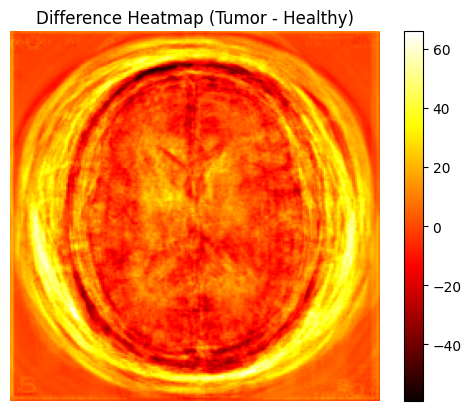

In [ ]:
diff = tumor_avg - healthy_avg

plt.imshow(diff, cmap='hot')
plt.colorbar()
plt.title("Difference Heatmap (Tumor - Healthy)")
plt.axis('off')
plt.show()

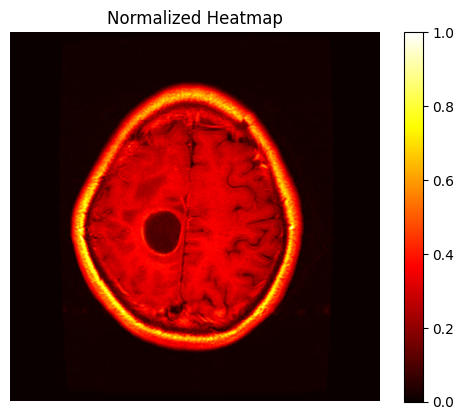

In [ ]:
img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

img_norm = img / 255.0

plt.imshow(img_norm, cmap='hot')
plt.colorbar()
plt.title("Normalized Heatmap")
plt.axis('off')
plt.show()

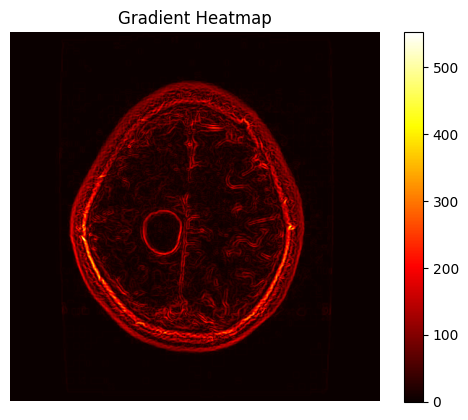

In [ ]:
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0)
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1)

gradient = np.sqrt(grad_x**2 + grad_y**2)

plt.imshow(gradient, cmap='hot')
plt.colorbar()
plt.title("Gradient Heatmap")
plt.axis('off')
plt.show()

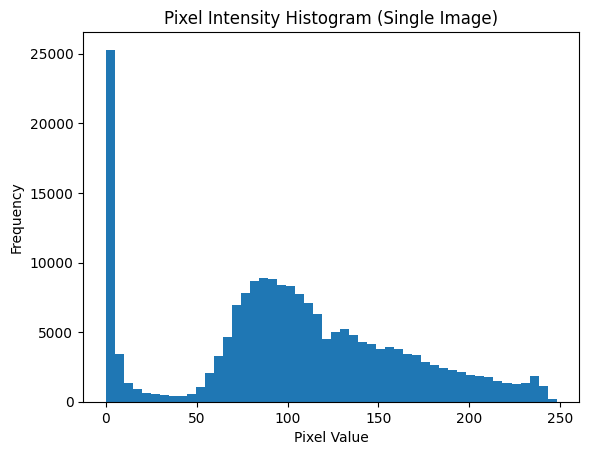

In [ ]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[1]))

plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Histogram (Single Image)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

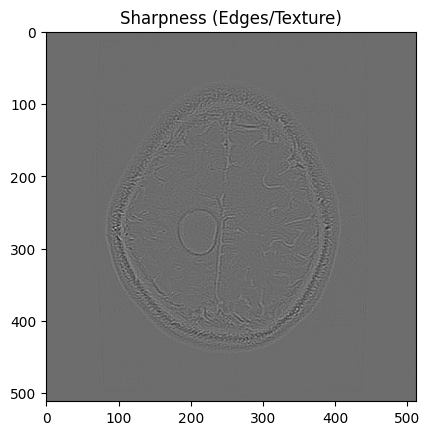

In [ ]:
import cv2

img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

plt.imshow(laplacian, cmap='gray')
plt.title("Sharpness (Edges/Texture)")
plt.show()

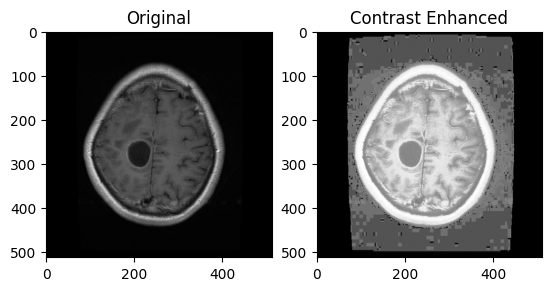

In [ ]:
import cv2

img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

# Increase contrast
contrast = cv2.equalizeHist(img)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Enhanced")

plt.show()

DAY 2 : Data Cleaning & Preprocessing

In [14]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from collections import Counter

In [15]:
CONFIG = {
    "IMG_SIZE": 224,
    "TUMOR_LABEL": 1,
    "HEALTHY_LABEL": 0
}

# 👉 UPDATE THESE PATHS
tumor_path = images_path
healthy_path = images_pathhealthy

In [16]:


def process_images(folder_path, label):
    data = []
    labels = []
    count = 0

    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path, 0)

            if img is None:
                continue

            # Resize
            img = cv2.resize(img, (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))

            # Normalize
            img = img.astype("float32") / 255.0

            data.append(img)
            labels.append(label)

            count += 1

        except Exception as e:
            print(f"Error processing {img_name}")

    return data, labels, count

In [17]:

print("Processing Tumor Images...")
tumor_data, tumor_labels, tumor_count = process_images(
    tumor_path, CONFIG["TUMOR_LABEL"]
)

print("Processing Healthy Images...")
healthy_data, healthy_labels, healthy_count = process_images(
    healthy_path, CONFIG["HEALTHY_LABEL"]
)

# Combine
data = tumor_data + healthy_data
labels = tumor_labels + healthy_labels

print(f"Tumor count: {tumor_count}")
print(f"Healthy count: {healthy_count}")


Processing Tumor Images...
Processing Healthy Images...
Tumor count: 2513
Healthy count: 2087


In [18]:
class_counts = Counter(labels)
print("Class Distribution:", class_counts)

Class Distribution: Counter({1: 2513, 0: 2087})


In [19]:
X = np.array(data)
y = np.array(labels)

print("Shape before reshape:", X.shape)

Shape before reshape: (4600, 224, 224)


In [20]:
X = X.reshape(-1, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"], 1)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (4600, 224, 224, 1)
Final y shape: (4600,)


In [21]:
X, y = shuffle(X, y, random_state=42)

print("Data shuffled")

Data shuffled


In [22]:
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [23]:

class_counts = Counter(y)
total = len(y)

print("\nClass Distribution:")
print(f"Tumor (1): {class_counts[1]}")
print(f"Healthy (0): {class_counts[0]}")

print("\nPercentage Distribution:")
print(f"Tumor: {class_counts[1]/total * 100:.2f}%")
print(f"Healthy: {class_counts[0]/total * 100:.2f}%")

imbalance_ratio = class_counts[1] / class_counts[0]

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

if imbalance_ratio < 1.5:
    print("No significant imbalance detected → No resampling required")
else:
    print("Significant imbalance → Resampling may be needed")


Class Distribution:
Tumor (1): 2513
Healthy (0): 2087

Percentage Distribution:
Tumor: 54.63%
Healthy: 45.37%

Imbalance Ratio: 1.2
No significant imbalance detected → No resampling required


In [ ]:
np.savez_compressed("brain_tumor_data.npz", X=X, y=y)

print("Data saved successfully!")

Data saved successfully!


Day 3- Data Pipeline

In [24]:
from sklearn.model_selection import train_test_split

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (3220, 224, 224, 1)
Val: (690, 224, 224, 1)
Test: (690, 224, 224, 1)


In [25]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val   = np.repeat(X_val, 3, axis=-1)
X_test  = np.repeat(X_test, 3, axis=-1)

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05
)

val_aug = ImageDataGenerator()

In [27]:
train_gen = train_aug.flow(
    X_train, y_train,
    batch_size=32
)

val_gen = val_aug.flow(
    X_val, y_val,
    batch_size=32
)

test_gen = val_aug.flow(
    X_test, y_test,
    batch_size=32,
    shuffle=False
)

In [28]:
images, labels = next(train_gen)

print("Batch shape:", images.shape)
print("Labels:", labels[:5])

Batch shape: (32, 224, 224, 3)
Labels: [0 0 1 0 1]


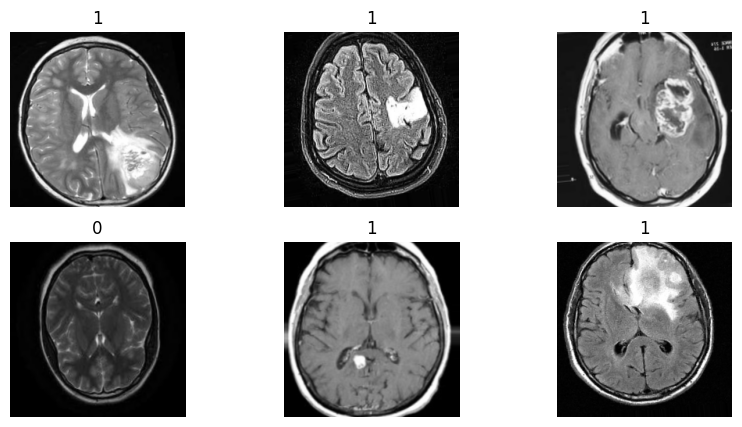

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(int(labels[i]))
    plt.axis('off')
plt.show()

day 4-Baseline Model

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten + Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(1, activation='sigmoid')   # binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 430ms/step - accuracy: 0.6674 - loss: 0.8064 - val_accuracy: 0.7710 - val_loss: 0.5187
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - accuracy: 0.7640 - loss: 0.4971 - val_accuracy: 0.7841 - val_loss: 0.4679
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 387ms/step - accuracy: 0.8047 - loss: 0.4393 - val_accuracy: 0.8203 - val_loss: 0.4040
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 378ms/step - accuracy: 0.8258 - loss: 0.3958 - val_accuracy: 0.8217 - val_loss: 0.3884
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 395ms/step - accuracy: 0.8379 - loss: 0.3632 - val_accuracy: 0.8681 - val_loss: 0.3159
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 390ms/step - accuracy: 0.8373 - loss: 0.3579 - val_accuracy: 0.7986 - val_loss: 0.4223
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 380ms/step - accuracy: 0.8512 - loss: 0.3360 - val_accuracy: 0.8812 - val_loss: 0.3360
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 391ms/step - accuracy: 0.8587 - loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(test_gen)

print(f"\n✅ Baseline Test Accuracy: {test_accuracy:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9290 - loss: 0.2094

✅ Baseline Test Accuracy: 0.9290


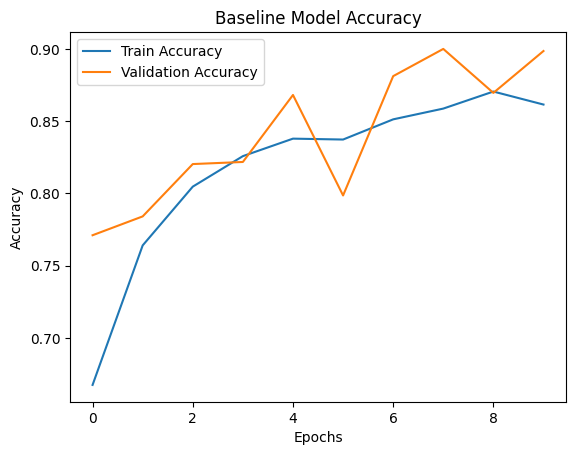

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model.save("model_baseline.h5")
print("Model saved successfully!")

Model saved successfully!


day 5: Advanced Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 62s 511ms/step - accuracy: 0.8388 - loss: 0.3654 - val_accuracy: 0.9130 - val_loss: 0.2009
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - accuracy: 0.9158 - loss: 0.2144 - val_accuracy: 0.9391 - val_loss: 0.1632
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 371ms/step - accuracy: 0.9345 - loss: 0.1741 - val_accuracy: 0.9377 - val_loss: 0.1628
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 391ms/step - accuracy: 0.9469 - loss: 0.1454 - val_accuracy: 0.9449 - val_loss: 0.1411
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 387ms/step - accuracy: 0.9509 - loss: 0.1326 - val_accuracy: 0.9449 - val_loss: 0.1421


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_mobilenet = models.Model(inputs=base_model.input, outputs=output)

model_mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_mob = model_mobilenet.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-30:]:
    layer.trainable = True

model_mobilenet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

history_mob_fine = model_mobilenet.fit(train_gen, validation_data=val_gen, epochs=5)

# Evaluate
mob_loss, mob_acc = model_mobilenet.evaluate(test_gen)
print("MobileNet Accuracy:", mob_acc)

model_mobilenet.save("model_mobilenet.h5")

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 57s 484ms/step - accuracy: 0.8323 - loss: 0.3597 - val_accuracy: 0.9145 - val_loss: 0.2066
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 366ms/step - accuracy: 0.9127 - loss: 0.2120 - val_accuracy: 0.9145 - val_loss: 0.1787
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 394ms/step - accuracy: 0.9339 - loss: 0.1743 - val_accuracy: 0.9072 - val_loss: 0.2051
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 401ms/step - accuracy: 0.9450 - loss: 0.1436 - val_accuracy: 0.9406 - val_loss: 0.1458
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 372ms/step - accuracy: 0.9565 - loss: 0.1207 - val_accuracy: 0.9290 - val_loss: 0.1537
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 71s 522ms/step - accuracy: 0.8280 - loss: 0.4349 - val_accuracy: 0.9101 - val_loss: 0.2324
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 42s 413ms/step - accuracy: 0.9084 - loss: 0.2145 - val_accuracy: 0.8913 - val_loss: 0.2973
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 42s 412ms/step - accuracy: 0.9267 - loss: 0.1704 - 

MobileNet Accuracy: 0.939130425453186


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_resnet = models.Model(inputs=base_model.input, outputs=output)

model_resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_res = model_resnet.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-40:]:
    layer.trainable = True

model_resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

history_res_fine = model_resnet.fit(train_gen, validation_data=val_gen, epochs=5)

# Evaluate
res_loss, res_acc = model_resnet.evaluate(test_gen)
print("ResNet Accuracy:", res_acc)

model_resnet.save("model_resnet.h5")

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 70s 555ms/step - accuracy: 0.6214 - loss: 0.6642 - val_accuracy: 0.6870 - val_loss: 0.6151
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 61s 425ms/step - accuracy: 0.6702 - loss: 0.6134 - val_accuracy: 0.5913 - val_loss: 0.6218
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 428ms/step - accuracy: 0.6677 - loss: 0.6040 - val_accuracy: 0.6377 - val_loss: 0.6809
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 422ms/step - accuracy: 0.6876 - loss: 0.5915 - val_accuracy: 0.7087 - val_loss: 0.5981
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 424ms/step - accuracy: 0.6848 - loss: 0.5883 - val_accuracy: 0.7101 - val_loss: 0.5832
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 87s 609ms/step - accuracy: 0.7227 - loss: 0.6961 - val_accuracy: 0.6420 - val_loss: 0.8915
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 424ms/step - accuracy: 0.8009 - loss: 0.4431 - val_accuracy: 0.7145 - val_loss: 0.7093
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 422ms/step - accuracy: 0.8177 - loss: 0.4098 - 

ResNet Accuracy: 0.9028985500335693


In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Head
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_vgg = model_vgg.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-20:]:
    layer.trainable = True

model_vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_vgg_fine = model_vgg.fit(train_gen, validation_data=val_gen, epochs=5)

# Evaluate
vgg_loss, vgg_acc = model_vgg.evaluate(test_gen)
print("VGG Accuracy:", vgg_acc)

model_vgg.save("model_vgg.h5")

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 82s 664ms/step - accuracy: 0.7519 - loss: 0.7731 - val_accuracy: 0.8667 - val_loss: 0.3036
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 473ms/step - accuracy: 0.8556 - loss: 0.3277 - val_accuracy: 0.8913 - val_loss: 0.2581
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.8975 - loss: 0.2501 - val_accuracy: 0.9217 - val_loss: 0.2034
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 460ms/step - accuracy: 0.9075 - loss: 0.2304 - val_accuracy: 0.9406 - val_loss: 0.1648
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 462ms/step - accuracy: 0.9214 - loss: 0.2056 - val_accuracy: 0.9449 - val_loss: 0.1483
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 135s 928ms/step - accuracy: 0.9385 - loss: 0.1477 - val_accuracy: 0.9768 - val_loss: 0.0877
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 64s 625ms/step - accuracy: 0.9693 - loss: 0.0875 - val_accuracy: 0.9768 - val_loss: 0.0668
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 64s 625ms/step - accuracy: 0.9792 - loss: 0.0620 -

VGG Accuracy: 0.9797101616859436


In [ ]:
print("\n===== Model Comparison =====")
print(f"MobileNet Accuracy: {mob_acc:.4f}")
print(f"ResNet Accuracy:    {res_acc:.4f}")
print(f"VGG Accuracy:       {vgg_acc:.4f}")


===== Model Comparison =====
MobileNet Accuracy: 0.9391
ResNet Accuracy:    0.9029
VGG Accuracy:       0.9797


In [ ]:
cnn_loss, cnn_acc = model.evaluate(test_gen)
print("CNN Accuracy:", cnn_acc)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9667 - loss: 0.1160
CNN Accuracy: 0.9666666388511658


In [ ]:
print("\n===== Model Comparison =====")

print(f"CNN (Baseline) Accuracy: {cnn_acc:.4f}")
print(f"MobileNet Accuracy:      {mob_acc:.4f}")
print(f"ResNet Accuracy:         {res_acc:.4f}")
print(f"VGG Accuracy:            {vgg_acc:.4f}")


===== Model Comparison =====
CNN (Baseline) Accuracy: 0.9667
MobileNet Accuracy:      0.9391
ResNet Accuracy:         0.9029
VGG Accuracy:            0.9797


Day 6 – Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Predictions
y_pred_cnn = (model.predict(test_gen) > 0.5).astype("int32")
y_pred_mob = (model_mobilenet.predict(test_gen) > 0.5).astype("int32")
y_pred_res = (model_resnet.predict(test_gen) > 0.5).astype("int32")
y_pred_vgg = (model_vgg.predict(test_gen) > 0.5).astype("int32")

# True labels
y_true = y_test

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step


In [ ]:
print("\n===== CNN =====")
print(classification_report(y_true, y_pred_cnn))

print("\n===== MobileNet =====")
print(classification_report(y_true, y_pred_mob))

print("\n===== ResNet =====")
print(classification_report(y_true, y_pred_res))

print("\n===== VGG =====")
print(classification_report(y_true, y_pred_vgg))


===== CNN =====
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       313
           1       0.96      0.98      0.97       377

    accuracy                           0.97       690
   macro avg       0.97      0.96      0.97       690
weighted avg       0.97      0.97      0.97       690


===== MobileNet =====
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       313
           1       0.99      0.89      0.94       377

    accuracy                           0.94       690
   macro avg       0.94      0.94      0.94       690
weighted avg       0.95      0.94      0.94       690


===== ResNet =====
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       313
           1       0.92      0.90      0.91       377

    accuracy                           0.90       690
   macro avg       0.90      0.90      0.90       690
weighted avg  

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

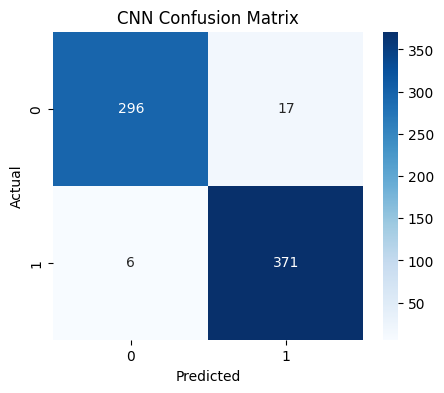

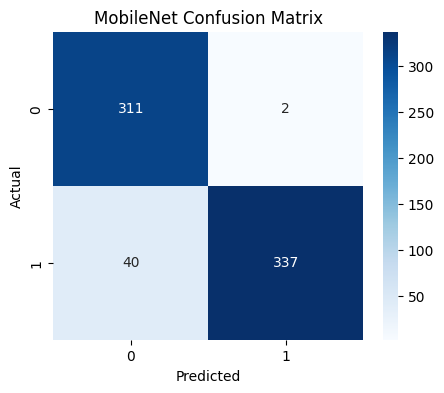

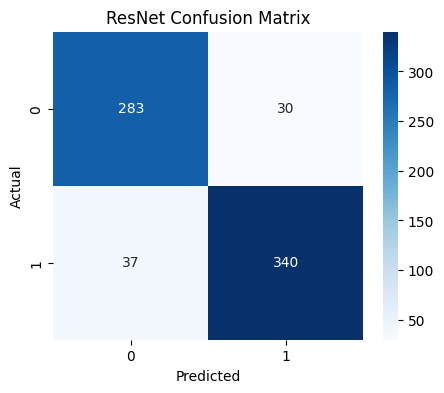

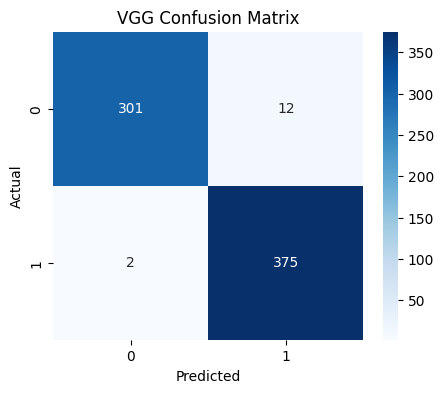

In [ ]:
plot_cm(y_true, y_pred_cnn, "CNN Confusion Matrix")
plot_cm(y_true, y_pred_mob, "MobileNet Confusion Matrix")
plot_cm(y_true, y_pred_res, "ResNet Confusion Matrix")
plot_cm(y_true, y_pred_vgg, "VGG Confusion Matrix")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

results = {
    "CNN": get_metrics(y_true, y_pred_cnn),
    "MobileNet": get_metrics(y_true, y_pred_mob),
    "ResNet": get_metrics(y_true, y_pred_res),
    "VGG": get_metrics(y_true, y_pred_vgg)
}

print("\n===== Final Metrics Comparison =====")
for model, metrics in results.items():
    print(f"{model}: Accuracy={metrics[0]:.4f}, Precision={metrics[1]:.4f}, Recall={metrics[2]:.4f}, F1={metrics[3]:.4f}")


===== Final Metrics Comparison =====
CNN: Accuracy=0.9667, Precision=0.9562, Recall=0.9841, F1=0.9699
MobileNet: Accuracy=0.9391, Precision=0.9941, Recall=0.8939, F1=0.9413
ResNet: Accuracy=0.9029, Precision=0.9189, Recall=0.9019, F1=0.9103
VGG: Accuracy=0.9797, Precision=0.9690, Recall=0.9947, F1=0.9817


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

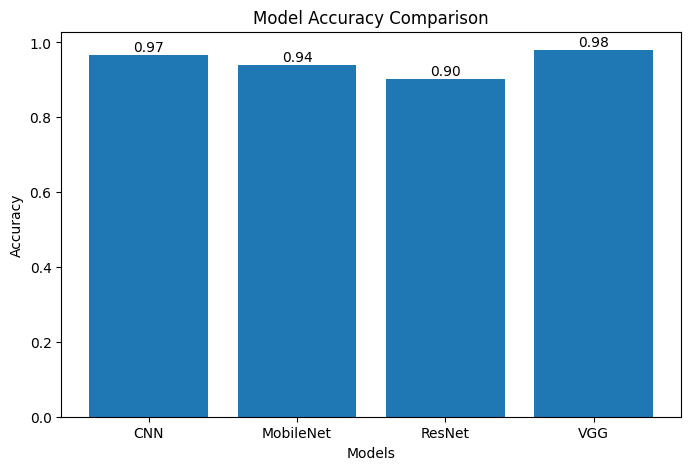

In [ ]:
import matplotlib.pyplot as plt

# Store results
models = ["CNN", "MobileNet", "ResNet", "VGG"]
accuracies = [cnn_acc, mob_acc, res_acc, vgg_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

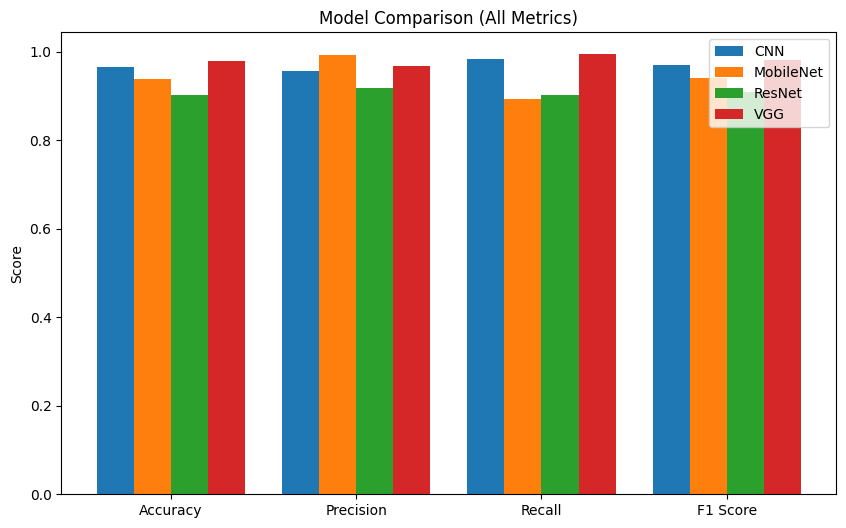

In [ ]:
import numpy as np

labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

cnn_metrics = get_metrics(y_true, y_pred_cnn)
mob_metrics = get_metrics(y_true, y_pred_mob)
res_metrics = get_metrics(y_true, y_pred_res)
vgg_metrics = get_metrics(y_true, y_pred_vgg)

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, cnn_metrics, width, label="CNN")
plt.bar(x - 0.5*width, mob_metrics, width, label="MobileNet")
plt.bar(x + 0.5*width, res_metrics, width, label="ResNet")
plt.bar(x + 1.5*width, vgg_metrics, width, label="VGG")

plt.xticks(x, labels)
plt.title("Model Comparison (All Metrics)")
plt.ylabel("Score")
plt.legend()

plt.show()

In [ ]:
best_model = max(
    {"CNN": cnn_acc, "MobileNet": mob_acc, "ResNet": res_acc, "VGG": vgg_acc},
    key=lambda x: {"CNN": cnn_acc, "MobileNet": mob_acc, "ResNet": res_acc, "VGG": vgg_acc}[x]
)

print("Best Model:", best_model)

Best Model: VGG


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

model_cnn_best = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model_cnn_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn_best = model_cnn_best.fit(train_gen, validation_data=val_gen, epochs=10)

cnn_best_loss, cnn_best_acc = model_cnn_best.evaluate(test_gen)
print("Improved CNN Accuracy:", cnn_best_acc)

model_cnn_best.save("best_cnn.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 54s 460ms/step - accuracy: 0.6522 - loss: 1.6954 - val_accuracy: 0.6652 - val_loss: 0.6408
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 404ms/step - accuracy: 0.6630 - loss: 0.5862 - val_accuracy: 0.5464 - val_loss: 2.0894
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 406ms/step - accuracy: 0.7311 - loss: 0.5220 - val_accuracy: 0.6536 - val_loss: 0.7540
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.7506 - loss: 0.4838 - val_accuracy: 0.7681 - val_loss: 0.5284
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 402ms/step - accuracy: 0.7894 - loss: 0.4272 - val_accuracy: 0.7130 - val_loss: 0.5654
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 407ms/step - accuracy: 0.7770 - loss: 0.4045 - val_accuracy: 0.8275 - val_loss: 0.3821
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 430ms/step - accuracy: 0.7944 - loss: 0.4024 - val_accuracy: 0.8768 - val_loss: 0.3166
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.8053 - loss: 0

Improved CNN Accuracy: 0.9028985500335693


In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)   # ✅ FIXED
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_mob_best = models.Model(inputs=base_model.input, outputs=output)

model_mob_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mob_best.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune more layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

model_mob_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mob_best.fit(train_gen, validation_data=val_gen, epochs=5)

mob_best_loss, mob_best_acc = model_mob_best.evaluate(test_gen)
print("Improved MobileNet Accuracy:", mob_best_acc)

model_mob_best.save("best_mobilenet.h5")

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 502ms/step - accuracy: 0.8056 - loss: 0.4302 - val_accuracy: 0.8957 - val_loss: 0.2882
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 371ms/step - accuracy: 0.9050 - loss: 0.2319 - val_accuracy: 0.9246 - val_loss: 0.2053
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 391ms/step - accuracy: 0.9314 - loss: 0.1767 - val_accuracy: 0.9319 - val_loss: 0.1597
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 396ms/step - accuracy: 0.9360 - loss: 0.1538 - val_accuracy: 0.9493 - val_loss: 0.1385
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 380ms/step - accuracy: 0.9506 - loss: 0.1247 - val_accuracy: 0.9420 - val_loss: 0.1348
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 80s 560ms/step - accuracy: 0.8543 - loss: 0.3512 - val_accuracy: 0.9000 - val_loss: 0.2591
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 399ms/step - accuracy: 0.9022 - loss: 0.2440 - val_accuracy: 0.8913 - val_loss: 0.3160
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 367ms/step - accuracy: 0.9248 - loss: 0.1822 - 

Improved MobileNet Accuracy: 0.9144927263259888


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)   # ✅ FIXED
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)
x = base_model.output
model_res_best = models.Model(inputs=base_model.input, outputs=output)

model_res_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_res_best.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-60:]:
    layer.trainable = True

model_res_best.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_res_best.fit(train_gen, validation_data=val_gen, epochs=5)

res_best_loss, res_best_acc = model_res_best.evaluate(test_gen)
print("Improved ResNet Accuracy:", res_best_acc)

model_res_best.save("best_resnet.h5")

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 66s 529ms/step - accuracy: 0.7171 - loss: 0.5563 - val_accuracy: 0.6493 - val_loss: 0.6357
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 65s 407ms/step - accuracy: 0.7568 - loss: 0.5013 - val_accuracy: 0.6913 - val_loss: 0.6145
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 419ms/step - accuracy: 0.7863 - loss: 0.4635 - val_accuracy: 0.7565 - val_loss: 0.5399
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 425ms/step - accuracy: 0.7941 - loss: 0.4429 - val_accuracy: 0.7884 - val_loss: 0.4937
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 427ms/step - accuracy: 0.8040 - loss: 0.4324 - val_accuracy: 0.7913 - val_loss: 0.4635
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 94s 623ms/step - accuracy: 0.7065 - loss: 0.6925 - val_accuracy: 0.5493 - val_loss: 1.0492
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 446ms/step - accuracy: 0.7646 - loss: 0.5433 - val_accuracy: 0.6652 - val_loss: 0.6920
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 446ms/step - accuracy: 0.7826 - loss: 0.5072 - 

Improved ResNet Accuracy: 0.8695651888847351


In [29]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.Flatten()(x)
x = layers.BatchNormalization()(x)   # ✅ FIX
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)


model_vgg_best = models.Model(inputs=base_model.input, outputs=output)

model_vgg_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg_best.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-25:]:
    layer.trainable = True

model_vgg_best.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg_best.fit(train_gen, validation_data=val_gen, epochs=5)

vgg_best_loss, vgg_best_acc = model_vgg_best.evaluate(test_gen)
print("Improved VGG Accuracy:", vgg_best_acc)

model_vgg_best.save("best_vgg.h5")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 82s 673ms/step - accuracy: 0.8506 - loss: 0.4941 - val_accuracy: 0.7913 - val_loss: 0.4271
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 465ms/step - accuracy: 0.9224 - loss: 0.2606 - val_accuracy: 0.9391 - val_loss: 0.1480
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 480ms/step - accuracy: 0.9413 - loss: 0.2021 - val_accuracy: 0.9609 - val_loss: 0.1087
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 475ms/step - accuracy: 0.9519 - loss: 0.1554 - val_accuracy: 0.9652 - val_loss: 0.1162
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 478ms/step - accuracy: 0.9640 - loss: 0.1217 - val_accuracy: 0.9797 - val_loss: 0.0932
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9661 - loss: 0.1163 - val_accuracy: 0.9754 - val_loss: 0.1095
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 66s 653ms/step - accuracy: 0.9733 - loss: 0.0833 - val_accuracy: 0.9739 - val_loss: 0.0957
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 66

Improved VGG Accuracy: 0.97826087474823


In [30]:
results = {
    "CNN": cnn_best_acc,
    "MobileNet": mob_best_acc,
    "ResNet": res_best_acc,
    "VGG": vgg_best_acc
}

best_model = max(results, key=results.get)

print("\n===== BEST MODEL =====")
print(best_model, ":", results[best_model])

NameError: name 'cnn_best_acc' is not defined